# Training Resnet18 with face data

The training data defines a classification problem from face to person. The dataset is a mix of VGG Face and FaceID 550. The data is copied from a GCS bucket into local storage, and carefully split into a train and test split *per person*. This means that all classes are represented in both train and test.

A previous training using a different script led to a few patterns:

* In one pair of runs, the TPU run never converged, while the GPU run did.
* In another pair of runs, the TPU converged but demonstrated slightly worse performance on train than the GPU run.

This notebook is an analysis of multiple training runs to demonstrate that:

* Training is noisy and empirical measures of difference must be measured using multiple runs and t-tests (e.g. error bars)
* The same high learning rate on two models with randomly initialized weights can lead to convergence in one model, but divergence in another.
* Training convergence in general benefits from adaptive optimizers, AdamW being the workhorse, warmups, learning rate schedules, and freezing pre-trained backbones while the new, random layers rapidly converge. 


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("metrics.csv", index_col=None, parse_dates=True)

## High learning rate

Under high learning rates, some weight initializations may result in no convergence at all. 

Note that 10.0 is indeed a very high learning rate, however, the batch size was manually tuned to 2048, creating roughly 300 million pixels per batch (2048 x 224 x 224 x 3). It's likely this batch size could be increased further for more recent TPUs and GPUs. 

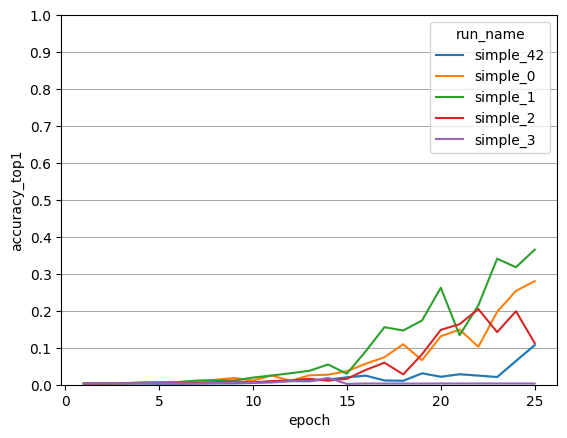

In [7]:
high_lr = df[df["run_name"].str.contains("simple") & df["hyperparameters"].str.contains("'lr': 10.0") & df["hyperparameters"].str.contains("xla")]
sns.lineplot(data=high_lr, x="epoch", y="accuracy_top1", hue="run_name", markers=True, dashes=False)
plt.ylim(0, 1)
plt.yticks([i/10 for i in range(11)])  # Ticks at 0.0, 0.1, ..., 1.0 (every 10%)
plt.grid(axis='y', which='both', color='gray', linestyle='-', linewidth=0.5)
plt.show()

# Middle learning rate

With a better tuned learning rate, we are able to consistently achieve about an 84% test accuracy. 

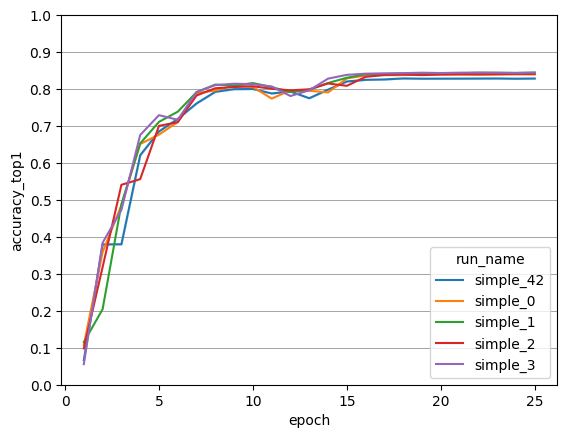

In [8]:
middle_lr = df[df["run_name"].str.contains("simple") & df["hyperparameters"].str.contains("'lr': 1.0") & df["hyperparameters"].str.contains("xla")]
sns.lineplot(data=middle_lr, x="epoch", y="accuracy_top1", hue="run_name", markers=True, dashes=False)
plt.ylim(0, 1)
plt.yticks([i/10 for i in range(11)])  # Ticks at 0.0, 0.1, ..., 1.0 (every 10%)
plt.grid(axis='y', which='both', color='gray', linestyle='-', linewidth=0.5)
plt.show()

## Low learning rate

An even lower learning rate will demonstrate even more stability and repeatability. It would eventually converge as well as the middle learning rate, however, it would require more epochs. Within the fixed 25 epoch budget, the model is still improving on test accuracy on epoch 25.

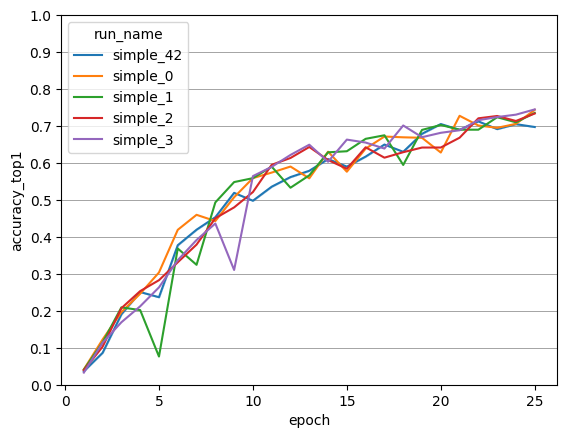

In [9]:
low_lr = df[df["run_name"].str.contains("simple") & df["hyperparameters"].str.contains("'lr': 0.1")  & df["hyperparameters"].str.contains("xla")]
sns.lineplot(data=low_lr, x="epoch", y="accuracy_top1", hue="run_name", markers=True, dashes=False)
plt.ylim(0, 1)
plt.yticks([i/10 for i in range(11)])  # Ticks at 0.0, 0.1, ..., 1.0 (every 10%)
plt.grid(axis='y', which='both', color='gray', linestyle='-', linewidth=0.5)
plt.show()

## A training setup closer to production

The training run previously used was simple. It used SGD, no momentum, and a fixed LR. Realistic production training runs should include:
* An empirically discovered maximum batch size to use up as much GPU/TPU memory as possible
* A warmup phase
* An empirically discovered high learning rate to speed up training without bordering on divergence
* An initial freeze of the backbone while the new layers adapt to the data and backbone, then an unfreeze
* Adaptive optimizers like AdamW or LAMB.

Combining these best practices, we are able to achieve an even high accuracy of around 88% consistently. This reduces the error rate from 18% to 12%, reducing error rate by a quarter. The runs are also more stable across runs between the same epoch. 

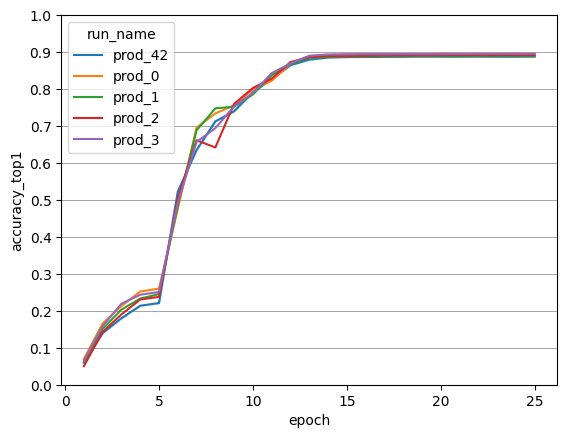

In [10]:
prod_tpu = df[df["run_name"].str.contains("prod") & df["hyperparameters"].str.contains("'lr': 0.003") & df["hyperparameters"].str.contains("xla")]
sns.lineplot(data=prod_tpu, x="epoch", y="accuracy_top1", hue="run_name", markers=True, dashes=False)
plt.ylim(0, 1)
plt.yticks([i/10 for i in range(11)])  # Ticks at 0.0, 0.1, ..., 1.0 (every 10%)
plt.grid(axis='y', which='both', color='gray', linestyle='-', linewidth=0.5)
plt.show()

# t-test for statistically confident measures of improvement

While we can easily eyeball the improvements using the best practices in training, when the improvement is less obvious, it is helpful to run a t-test. Doing so here gives us the off-the-charts 4.8e-07, indicating a very nearly 100% confidence that the production-like runs are an improvement over the simpler approach. 

In [11]:
from scipy.stats import ttest_ind

middle_lr_top1 = middle_lr[middle_lr["epoch"] == 25]["accuracy_top1"].values
prod_top1 = prod_tpu[prod_tpu["epoch"] == 25]["accuracy_top1"].values

t_stat, p_two_sided = ttest_ind(prod_top1, middle_lr_top1, equal_var=False)  # Welch’s t-test

# Convert to one-sided p-value (B > A)
p_one_sided = p_two_sided / 2 if t_stat > 0 else 1 - (p_two_sided / 2)

print(f"p-value (B > A) (lower is better): {p_one_sided}")

p-value (B > A) (lower is better): 3.7324384601662906e-07


## TPU vs GPU

With statistically significant tests and multiple runs on TPU and GPU, we can now make a direct comparison on convergence. Note that this is NOT a measure of TCO. For that, we would need to further tune the hyperparameters for optimal convergence, and then compare against the price. 

Let's plot the five TPU runs in blue and five GPU runs in red and see if we can eyeball a difference.

/var/tmp/ipykernel_370028/1012135078.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prod_tpu_labeled['device_type'] = 'TPU'
/var/tmp/ipykernel_370028/1012135078.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prod_gpu_labeled['device_type'] = 'GPU'


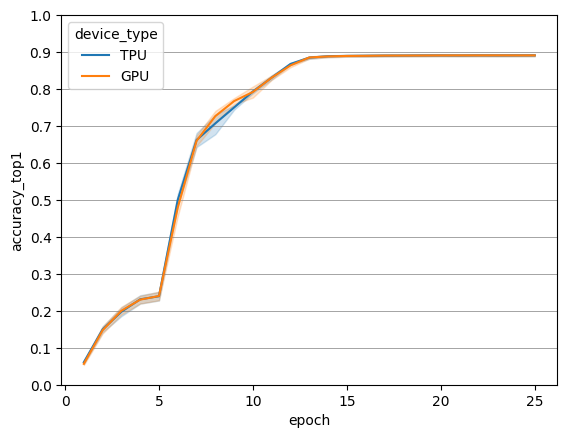

In [12]:
prod_tpu_labeled = df[df["run_name"].str.contains("prod") & df["hyperparameters"].str.contains("'lr': 0.003") & df["hyperparameters"].str.contains("xla")]
prod_tpu_labeled['device_type'] = 'TPU'

prod_gpu_labeled = df[df["run_name"].str.contains("prod") & df["hyperparameters"].str.contains("'lr': 0.003") & df["hyperparameters"].str.contains("cuda")]
prod_gpu_labeled['device_type'] = 'GPU'

# Combine the datasets
combined_data = pd.concat([prod_tpu_labeled, prod_gpu_labeled])

# Plot with device_type as hue instead of run_name
sns.lineplot(data=combined_data, x="epoch", y="accuracy_top1", hue="device_type", markers=True, dashes=False)
plt.ylim(0, 1)
plt.yticks([i/10 for i in range(11)])  # Ticks at 0.0, 0.1, ..., 1.0 (every 10%)
plt.grid(axis='y', which='both', color='gray', linestyle='-', linewidth=0.5)
plt.show()

## t-test

The plot doesn't really indicate any difference. Let's run a t-test and see if there's a difference between the two. 

In [13]:
tpu_top1 = prod_tpu_labeled[prod_tpu_labeled["epoch"] == 25]["accuracy_top1"].values
gpu_top1 = prod_gpu_labeled[prod_gpu_labeled["epoch"] == 25]["accuracy_top1"].values

print("TPU Top-1 Accuracy:", tpu_top1)
print("GPU Top-1 Accuracy:", gpu_top1)

t_stat, p_two_sided = ttest_ind(tpu_top1, gpu_top1, equal_var=False)  # Welch’s t-test

print(f"p-value (B != A) (lower is better): {p_two_sided}")

TPU Top-1 Accuracy: [0.8879 0.8879 0.8953 0.889  0.8917 0.8954]
GPU Top-1 Accuracy: [0.8879 0.887  0.8958 0.8929 0.89   0.8932]
p-value (B != A) (lower is better): 0.973990734293781


# GPU vs TPU t-test results

The intuition we gained from the chart is validated by the t-test. The chart seemed to show two overlapping lines, and the the t-test also indicates that there is only a 2.7% chance that the two curves differ. If we were to pick just one pair of values, say, the fourth column, 0.889 vs 0.8929, we might estimate a 4% difference between the two - but that is better explained as noise. 